# ICU Mechanical Ventilation Prediction

This notebook explores various machine learning models and techniques for predicting the need for mechanical ventilation in an ICU setting. The primary target is `y_high` (1 = ventilation needed in the next 6–12 hours), and the key evaluation metric for this imbalanced dataset is AUPRC (Area Under the Precision-Recall Curve).

Models covered:
- Logistic Regression
- Random Forest
- XGBoost

Imbalance handling techniques explored:
- `class_weight` parameter in Logistic Regression and Random Forest
- `scale_pos_weight` parameter in XGBoost
- SMOTE, SMOTE + Tomek, and ADASYN oversampling strategies combined with XGBoost and Random Forest.

## Logistic Regression

Train size : (109474, 31)  |  Positives: 250 (0.23%)
Test  size : (27393, 31)   |  Positives: 48 (0.18%)

Model trained ✓

  AUPRC (primary metric) : 0.0015
  AUROC                  : 0.4001

Classification Report (threshold = 0.5):
              precision    recall  f1-score   support

     No Vent       1.00      0.64      0.78     27345
        Vent       0.00      0.10      0.00        48

    accuracy                           0.64     27393
   macro avg       0.50      0.37      0.39     27393
weighted avg       1.00      0.64      0.78     27393



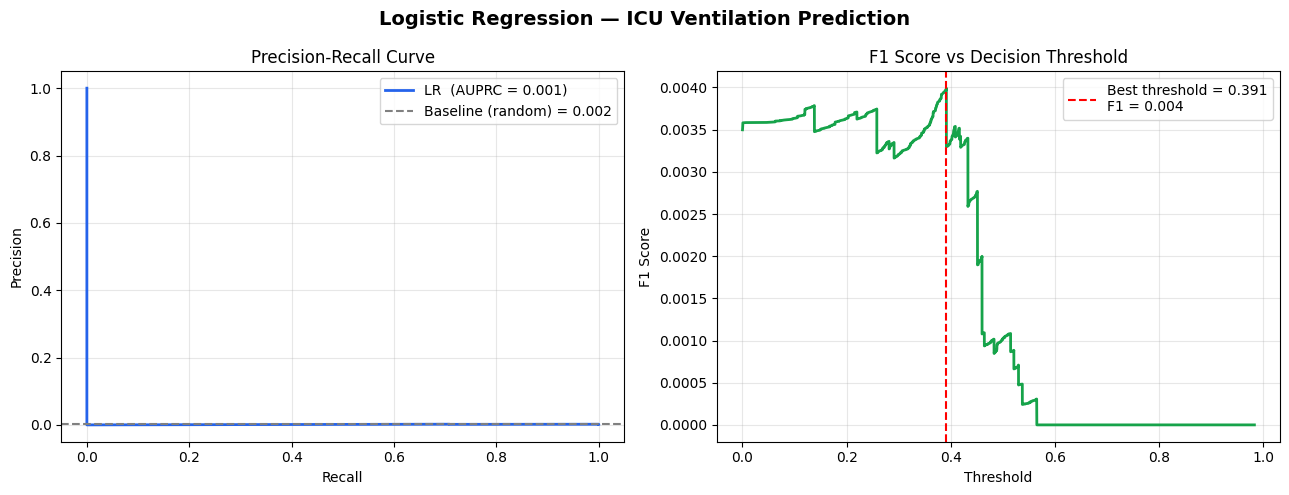


Plot saved → pr_curve.png

--- Re-evaluated at best F1 threshold (0.391) ---
              precision    recall  f1-score   support

     No Vent       1.00      0.38      0.55     27345
        Vent       0.00      0.71      0.00        48

    accuracy                           0.38     27393
   macro avg       0.50      0.54      0.28     27393
weighted avg       1.00      0.38      0.55     27393



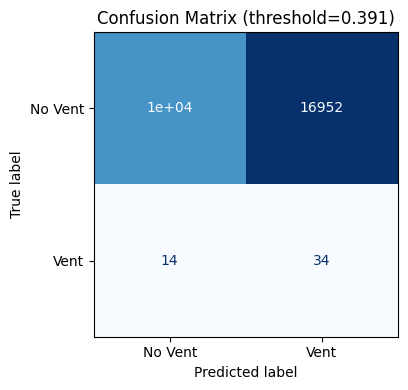

Plot saved → confusion_matrix.png

Top 10 most influential features:
unittype_Neuro ICU      -1.120436
heartrate_mean_3h        0.294732
sao2_std_3h             -0.280655
on_oxygen_therapy       -0.271981
unittype_CSICU           0.270159
unittype_Med-Surg ICU    0.267742
respiration_mean_3h      0.234082
unittype_Cardiac ICU     0.230264
age                      0.209837
fio2_last                0.202113


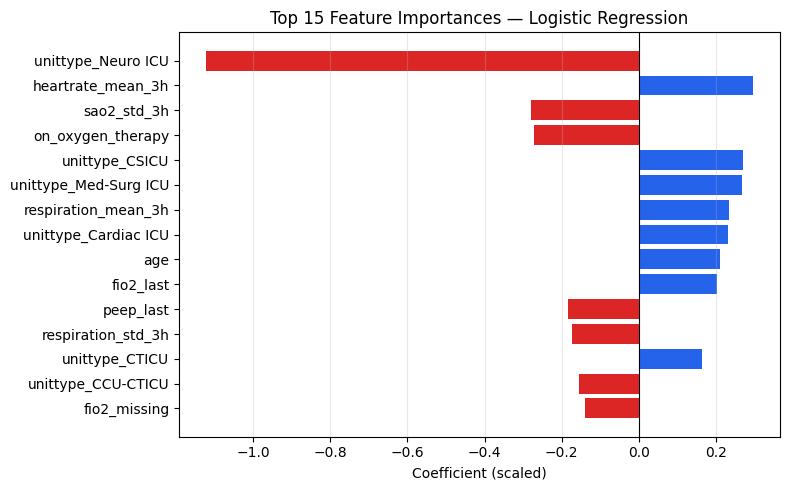

Plot saved → feature_importance.png


In [ ]:
"""
Logistic Regression — ICU Mechanical Ventilation Prediction
Target: y_high (1 = ventilation needed in next 6–12h)
Metric: AUPRC (area under Precision-Recall curve) — preferred for imbalanced data
Class imbalance handled via: class_weight='balanced'
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── 1. Load data ──────────────────────────────────────────────────────────────
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

print(f"Train size : {X_train.shape}  |  Positives: {y_train.sum()} ({y_train.mean()*100:.2f}%)")
print(f"Test  size : {X_test.shape}   |  Positives: {y_test.sum()} ({y_test.mean()*100:.2f}%)")

# ── 2. Model pipeline ─────────────────────────────────────────────────────────
# StandardScaler is essential for Logistic Regression convergence
# class_weight='balanced' → automatically weights minority class up
#   weight_minority = n_total / (2 * n_minority)

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        class_weight="balanced",   # handles imbalance (~437:1 here)
        max_iter=1000,
        solver="lbfgs",
        C=1.0,                     # inverse regularization strength
        random_state=42,
    ))
])

# ── 3. Train ──────────────────────────────────────────────────────────────────
pipeline.fit(X_train, y_train)
print("\nModel trained ✓")

# ── 4. Predict ────────────────────────────────────────────────────────────────
y_prob = pipeline.predict_proba(X_test)[:, 1]   # probability of class 1
y_pred = pipeline.predict(X_test)               # default threshold = 0.5

# ── 5. Evaluate ───────────────────────────────────────────────────────────────
auprc  = average_precision_score(y_test, y_prob)
auroc  = roc_auc_score(y_test, y_prob)

print(f"\n{'='*45}")
print(f"  AUPRC (primary metric) : {auprc:.4f}")
print(f"  AUROC                  : {auroc:.4f}")
print(f"{'='*45}")
print("\nClassification Report (threshold = 0.5):")
print(classification_report(y_test, y_pred, target_names=["No Vent", "Vent"]))

# ── 6. Precision-Recall Curve ─────────────────────────────────────────────────
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Logistic Regression — ICU Ventilation Prediction", fontsize=14, fontweight="bold")

# — PR Curve —
ax = axes[0]
ax.plot(recall, precision, color="#2563eb", lw=2, label=f"LR  (AUPRC = {auprc:.3f})")
baseline = y_test.mean()
ax.axhline(baseline, color="gray", linestyle="--", label=f"Baseline (random) = {baseline:.3f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
ax.grid(alpha=0.3)

# — F1 vs Threshold —
ax = axes[1]
f1_scores = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-8)
best_idx  = np.argmax(f1_scores)
best_thr  = thresholds[best_idx]
ax.plot(thresholds, f1_scores, color="#16a34a", lw=2)
ax.axvline(best_thr, color="red", linestyle="--",
           label=f"Best threshold = {best_thr:.3f}\nF1 = {f1_scores[best_idx]:.3f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs Decision Threshold")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nPlot saved → pr_curve.png")

# ── 7. Best-threshold evaluation ──────────────────────────────────────────────
print(f"\n--- Re-evaluated at best F1 threshold ({best_thr:.3f}) ---")
y_pred_best = (y_prob >= best_thr).astype(int)
print(classification_report(y_test, y_pred_best, target_names=["No Vent", "Vent"]))

fig2, ax2 = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test, y_pred_best)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Vent", "Vent"])
disp.plot(ax=ax2, colorbar=False, cmap="Blues")
ax2.set_title(f"Confusion Matrix (threshold={best_thr:.3f})")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → confusion_matrix.png")

# ── 8. Feature importance (coefficients) ─────────────────────────────────────
coef = pipeline.named_steps["clf"].coef_[0]
feat_imp = pd.Series(coef, index=X_train.columns).sort_values(key=abs, ascending=False)

print("\nTop 10 most influential features:")
print(feat_imp.head(10).to_string())

fig3, ax3 = plt.subplots(figsize=(8, 5))
top_feats = feat_imp.head(15)
colors = ["#2563eb" if v > 0 else "#dc2626" for v in top_feats.values]
ax3.barh(top_feats.index[::-1], top_feats.values[::-1], color=colors[::-1])
ax3.axvline(0, color="black", lw=0.8)
ax3.set_xlabel("Coefficient (scaled)")
ax3.set_title("Top 15 Feature Importances — Logistic Regression")
ax3.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved → feature_importance.png")

## Random Forest

Train : (109474, 31)  |  Pos=250  Neg=109224  Ratio=436.9:1
Test  : (27393, 31)   |  Pos=48  Neg=27345

Training Random Forest ...
Done ✓

  AUPRC (primary metric) : 0.0031
  AUROC                  : 0.6450

Best threshold (max F1) : 0.400
Best F1 score           : 0.011

Classification Report (threshold=0.400):
              precision    recall  f1-score   support

     No Vent       1.00      0.84      0.91     27345
        Vent       0.01      0.50      0.01        48

    accuracy                           0.84     27393
   macro avg       0.50      0.67      0.46     27393
weighted avg       1.00      0.84      0.91     27393



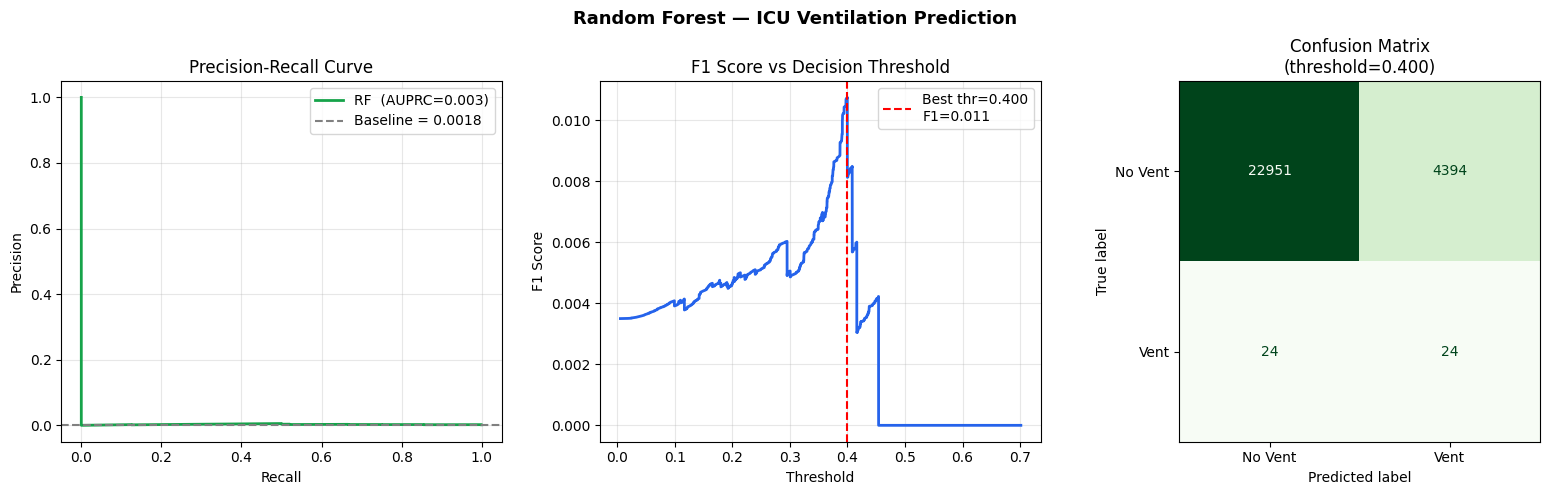


Saved → random_forest_results.png

Top 15 features:
age                    0.204094
admissionweight        0.141510
heartrate_mean_3h      0.067986
fio2_last              0.062188
heartrate_last         0.046683
respiration_mean_3h    0.044040
respiration_std_3h     0.036319
respiration_last       0.032532
sao2_mean_3h           0.029517
heartrate_slope_3h     0.027515
gender_Female          0.027240
heartrate_std_3h       0.026525
on_oxygen_therapy      0.026096
sao2_std_3h            0.024514
gender_Male            0.024493


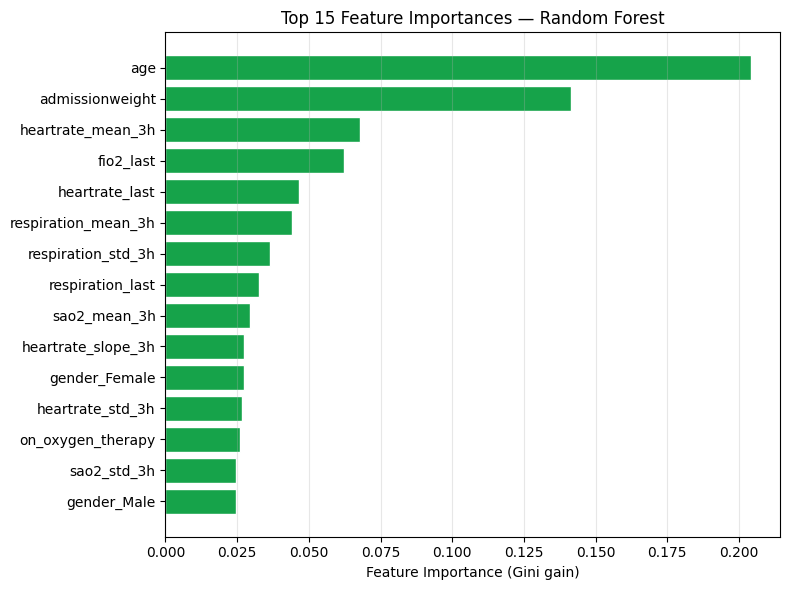

Saved → random_forest_feature_importance.png


In [2]:
"""
Random Forest — ICU Mechanical Ventilation Prediction
======================================================
Target    : y_high (1 = ventilation needed in next 6–12h)
Imbalance : class_weight='balanced_subsample' (re-balances each bootstrap)
Metric    : AUPRC (Area Under Precision-Recall Curve)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── 1. Load data ──────────────────────────────────────────────────────────────
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

pos   = y_train.sum()
neg   = (y_train == 0).sum()
ratio = neg / pos

print(f"Train : {X_train.shape}  |  Pos={pos}  Neg={neg}  Ratio={ratio:.1f}:1")
print(f"Test  : {X_test.shape}   |  Pos={y_test.sum()}  Neg={(y_test==0).sum()}")

# ── 2. Model ──────────────────────────────────────────────────────────────────
# class_weight='balanced_subsample':
#   re-computes class weights on every bootstrap sample → better than
#   'balanced' for highly imbalanced data in forests

rf = RandomForestClassifier(
    n_estimators=300,           # number of trees
    max_depth=10,               # limit depth to avoid overfitting
    min_samples_leaf=10,        # min samples per leaf node
    max_features="sqrt",        # features considered per split
    class_weight="balanced_subsample",
    n_jobs=-1,                  # use all CPU cores
    random_state=42,
)

# ── 3. Train ──────────────────────────────────────────────────────────────────
print("\nTraining Random Forest ...")
rf.fit(X_train, y_train)
print("Done ✓")

# ── 4. Predict ────────────────────────────────────────────────────────────────
y_prob = rf.predict_proba(X_test)[:, 1]   # probability of class=1 (Vent)

# ── 5. Core metrics ───────────────────────────────────────────────────────────
auprc = average_precision_score(y_test, y_prob)
auroc = roc_auc_score(y_test, y_prob)

print(f"\n{'='*40}")
print(f"  AUPRC (primary metric) : {auprc:.4f}")
print(f"  AUROC                  : {auroc:.4f}")
print(f"{'='*40}")

# ── 6. Best threshold by F1 ───────────────────────────────────────────────────
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = (2 * precision_vals[:-1] * recall_vals[:-1]
             / (precision_vals[:-1] + recall_vals[:-1] + 1e-8))
best_idx = np.argmax(f1_scores)
best_thr = thresholds[best_idx]
best_f1  = f1_scores[best_idx]

print(f"\nBest threshold (max F1) : {best_thr:.3f}")
print(f"Best F1 score           : {best_f1:.3f}")

y_pred = (y_prob >= best_thr).astype(int)

print(f"\nClassification Report (threshold={best_thr:.3f}):")
print(classification_report(y_test, y_pred, target_names=["No Vent", "Vent"]))

# ── 7. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Random Forest — ICU Ventilation Prediction", fontsize=13, fontweight="bold")

# — Precision-Recall Curve —
ax = axes[0]
baseline = y_test.mean()
ax.plot(recall_vals, precision_vals, color="#16a34a", lw=2,
        label=f"RF  (AUPRC={auprc:.3f})")
ax.axhline(baseline, color="gray", linestyle="--",
           label=f"Baseline = {baseline:.4f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
ax.grid(alpha=0.3)

# — F1 vs Threshold —
ax = axes[1]
ax.plot(thresholds, f1_scores, color="#2563eb", lw=2)
ax.axvline(best_thr, color="red", linestyle="--",
           label=f"Best thr={best_thr:.3f}\nF1={best_f1:.3f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs Decision Threshold")
ax.legend()
ax.grid(alpha=0.3)

# — Confusion Matrix —
ax = axes[2]
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Vent", "Vent"])
disp.plot(ax=ax, colorbar=False, cmap="Greens")
ax.set_title(f"Confusion Matrix\n(threshold={best_thr:.3f})")

plt.tight_layout()
plt.savefig("random_forest_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → random_forest_results.png")

# ── 8. Feature importance ─────────────────────────────────────────────────────
imp = pd.Series(rf.feature_importances_, index=X_train.columns)
imp = imp.sort_values(ascending=False)

print("\nTop 15 features:")
print(imp.head(15).to_string())

fig2, ax2 = plt.subplots(figsize=(8, 6))
top15 = imp.head(15)
ax2.barh(top15.index[::-1], top15.values[::-1], color="#16a34a", edgecolor="white")
ax2.set_xlabel("Feature Importance (Gini gain)")
ax2.set_title("Top 15 Feature Importances — Random Forest")
ax2.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("random_forest_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → random_forest_feature_importance.png")

## XGBoost

Train : (109474, 31)  |  Pos=250  Neg=109224  scale_pos_weight=436.9
Test  : (27393, 31)   |  Pos=48  Neg=27345

Training XGBoost ...
[0]	validation_0-aucpr:0.00215
[48]	validation_0-aucpr:0.00212

Best iteration: 18

  AUPRC (primary metric) : 0.0032
  AUROC                  : 0.6319

Best threshold (max F1) : 0.568
Best F1 score           : 0.012

Classification Report (threshold=0.568):
              precision    recall  f1-score   support

     No Vent       1.00      0.95      0.98     27345
        Vent       0.01      0.17      0.01        48

    accuracy                           0.95     27393
   macro avg       0.50      0.56      0.49     27393
weighted avg       1.00      0.95      0.97     27393



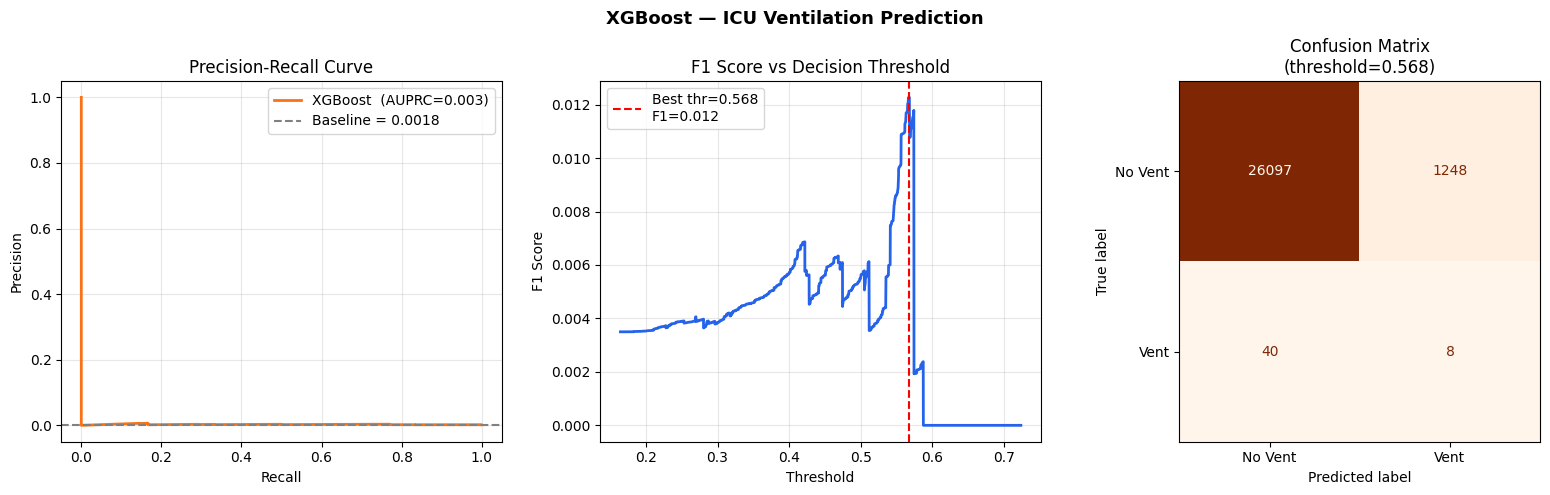


Saved → xgboost_results.png


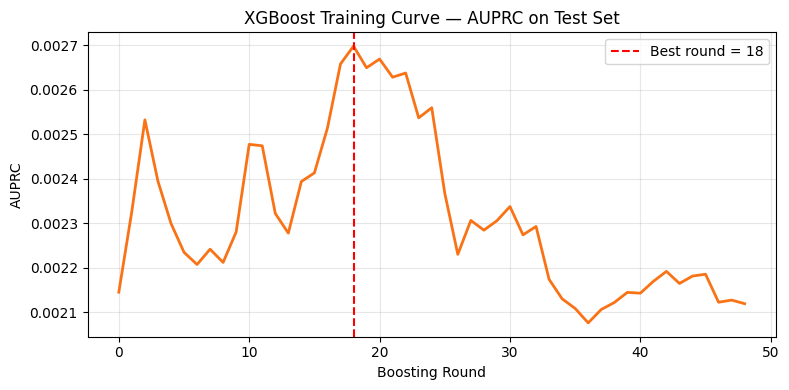

Saved → xgboost_training_curve.png

Top 15 features:
unittype_MICU           0.061556
unittype_CCU-CTICU      0.059043
respiration_last        0.052138
age                     0.047824
admissionweight         0.045849
unittype_Cardiac ICU    0.044083
respiration_mean_3h     0.043921
fio2_last               0.041577
sao2_last               0.033845
heartrate_slope_3h      0.033756
peep_last               0.033239
on_oxygen_therapy       0.032656
unittype_CTICU          0.032295
fio2_missing            0.032089
unittype_Neuro ICU      0.031922


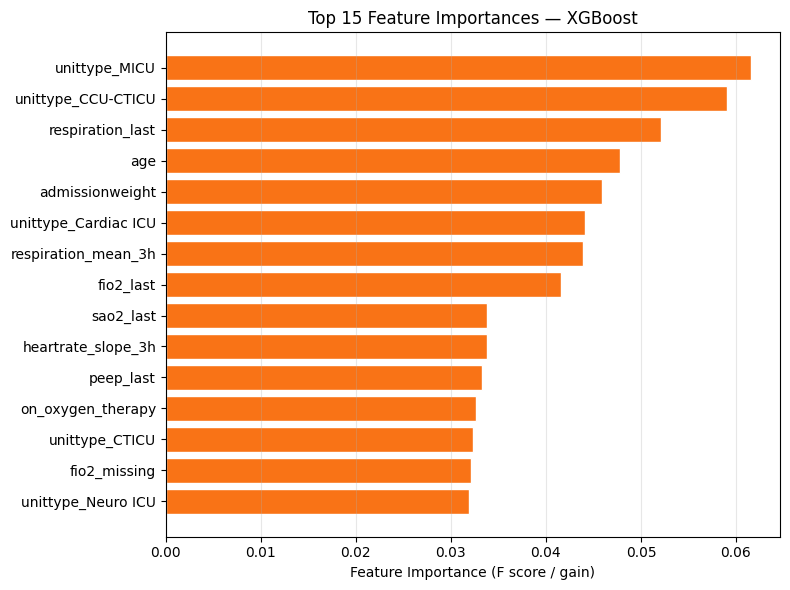

Saved → xgboost_feature_importance.png


In [5]:
"""
XGBoost — ICU Mechanical Ventilation Prediction
================================================
Install  : pip install xgboost
Target   : y_high (1 = ventilation needed in next 6–12h)
Imbalance: scale_pos_weight = neg/pos  (XGBoost's built-in imbalance handler)
Metric   : AUPRC (Area Under Precision-Recall Curve)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import xgboost as xgb
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── 1. Load data ──────────────────────────────────────────────────────────────
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

pos   = int(y_train.sum())
neg   = int((y_train == 0).sum())
scale_pos_weight = neg / pos   # ~436.9 — tells XGBoost how much to upweight positives

print(f"Train : {X_train.shape}  |  Pos={pos}  Neg={neg}  scale_pos_weight={scale_pos_weight:.1f}")
print(f"Test  : {X_test.shape}   |  Pos={y_test.sum()}  Neg={(y_test==0).sum()}")

# ── 2. Model ──────────────────────────────────────────────────────────────────
# Key parameters for imbalanced clinical data:
#   scale_pos_weight : compensates for class imbalance (equivalent to class_weight)
#   eval_metric      : aucpr = AUPRC, used for early stopping
#   max_depth        : controls tree complexity / overfitting
#   subsample        : row sampling per tree (reduces overfitting)
#   colsample_bytree : feature sampling per tree (reduces overfitting)

model = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=10,          # min sum of instance weight in a child (like min_samples_leaf)
    subsample=0.8,                # 80% of rows per tree
    colsample_bytree=0.8,         # 80% of features per tree
    scale_pos_weight=scale_pos_weight,  # handles 437:1 imbalance
    eval_metric="aucpr",          # optimise AUPRC during training
    early_stopping_rounds=30,     # stop if no improvement for 30 rounds
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)

# ── 3. Train with early stopping ──────────────────────────────────────────────
print("\nTraining XGBoost ...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=50,                   # print every 50 rounds
)
print(f"\nBest iteration: {model.best_iteration}")

# ── 4. Predict ────────────────────────────────────────────────────────────────
y_prob = model.predict_proba(X_test)[:, 1]

# ── 5. Core metrics ───────────────────────────────────────────────────────────
auprc = average_precision_score(y_test, y_prob)
auroc = roc_auc_score(y_test, y_prob)

print(f"\n{'='*40}")
print(f"  AUPRC (primary metric) : {auprc:.4f}")
print(f"  AUROC                  : {auroc:.4f}")
print(f"{'='*40}")

# ── 6. Best threshold by F1 ───────────────────────────────────────────────────
precision_vals, recall_vals, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = (2 * precision_vals[:-1] * recall_vals[:-1]
             / (precision_vals[:-1] + recall_vals[:-1] + 1e-8))
best_idx = np.argmax(f1_scores)
best_thr = thresholds[best_idx]
best_f1  = f1_scores[best_idx]

print(f"\nBest threshold (max F1) : {best_thr:.3f}")
print(f"Best F1 score           : {best_f1:.3f}")

y_pred = (y_prob >= best_thr).astype(int)

print(f"\nClassification Report (threshold={best_thr:.3f}):")
print(classification_report(y_test, y_pred, target_names=["No Vent", "Vent"]))

# ── 7. Plots ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("XGBoost — ICU Ventilation Prediction", fontsize=13, fontweight="bold")

# — Precision-Recall Curve —
ax = axes[0]
baseline = y_test.mean()
ax.plot(recall_vals, precision_vals, color="#f97316", lw=2,
        label=f"XGBoost  (AUPRC={auprc:.3f})")
ax.axhline(baseline, color="gray", linestyle="--",
           label=f"Baseline = {baseline:.4f}")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve")
ax.legend()
ax.grid(alpha=0.3)

# — F1 vs Threshold —
ax = axes[1]
ax.plot(thresholds, f1_scores, color="#2563eb", lw=2)
ax.axvline(best_thr, color="red", linestyle="--",
           label=f"Best thr={best_thr:.3f}\nF1={best_f1:.3f}")
ax.set_xlabel("Threshold")
ax.set_ylabel("F1 Score")
ax.set_title("F1 Score vs Decision Threshold")
ax.legend()
ax.grid(alpha=0.3)

# — Confusion Matrix —
ax = axes[2]
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No Vent", "Vent"])
disp.plot(ax=ax, colorbar=False, cmap="Oranges")
ax.set_title(f"Confusion Matrix\n(threshold={best_thr:.3f})")

plt.tight_layout()
plt.savefig("xgboost_results.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → xgboost_results.png")

# ── 8. Training curve (AUPRC over boosting rounds) ───────────────────────────
results_log = model.evals_result()
aucpr_scores = results_log["validation_0"]["aucpr"]

fig2, ax2 = plt.subplots(figsize=(8, 4))
ax2.plot(aucpr_scores, color="#f97316", lw=2)
ax2.axvline(model.best_iteration, color="red", linestyle="--",
            label=f"Best round = {model.best_iteration}")
ax2.set_xlabel("Boosting Round")
ax2.set_ylabel("AUPRC")
ax2.set_title("XGBoost Training Curve — AUPRC on Test Set")
ax2.legend()
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("xgboost_training_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → xgboost_training_curve.png")

# ── 9. Feature importance ─────────────────────────────────────────────────────
imp = pd.Series(model.feature_importances_, index=X_train.columns)
imp = imp.sort_values(ascending=False)

print("\nTop 15 features:")
print(imp.head(15).to_string())

fig3, ax3 = plt.subplots(figsize=(8, 6))
top15 = imp.head(15)
ax3.barh(top15.index[::-1], top15.values[::-1], color="#f97316", edgecolor="white")
ax3.set_xlabel("Feature Importance (F score / gain)")
ax3.set_title("Top 15 Feature Importances — XGBoost")
ax3.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("xgboost_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → xgboost_feature_importance.png")

## SMOTE Strategies with XGBoost

Train : (109474, 31)  |  Pos=250  Neg=109224  Ratio=436.9:1
Test  : (27393, 31)   |  Pos=48  Neg=27345

───────────────────────────────────────────────────────
Strategy: SMOTE
  Resampling training data ...
  After resampling → Pos=10922  Neg=109224  Ratio=10.0:1
  Training XGBoost ...
  AUPRC : 0.0030  |  AUROC : 0.5899  |  Best F1 : 0.020  |  Best thr : 0.138

───────────────────────────────────────────────────────
Strategy: SMOTE + Tomek
  Resampling training data ...
  After resampling → Pos=10922  Neg=109224  Ratio=10.0:1
  Training XGBoost ...
  AUPRC : 0.0030  |  AUROC : 0.5899  |  Best F1 : 0.020  |  Best thr : 0.138

───────────────────────────────────────────────────────
Strategy: ADASYN
  Resampling training data ...
  After resampling → Pos=10967  Neg=109224  Ratio=10.0:1
  Training XGBoost ...
  AUPRC : 0.0043  |  AUROC : 0.6358  |  Best F1 : 0.022  |  Best thr : 0.102

Strategy                AUPRC     AUROC   Best F1
SMOTE                  0.0030    0.5899     0.020
SMOT

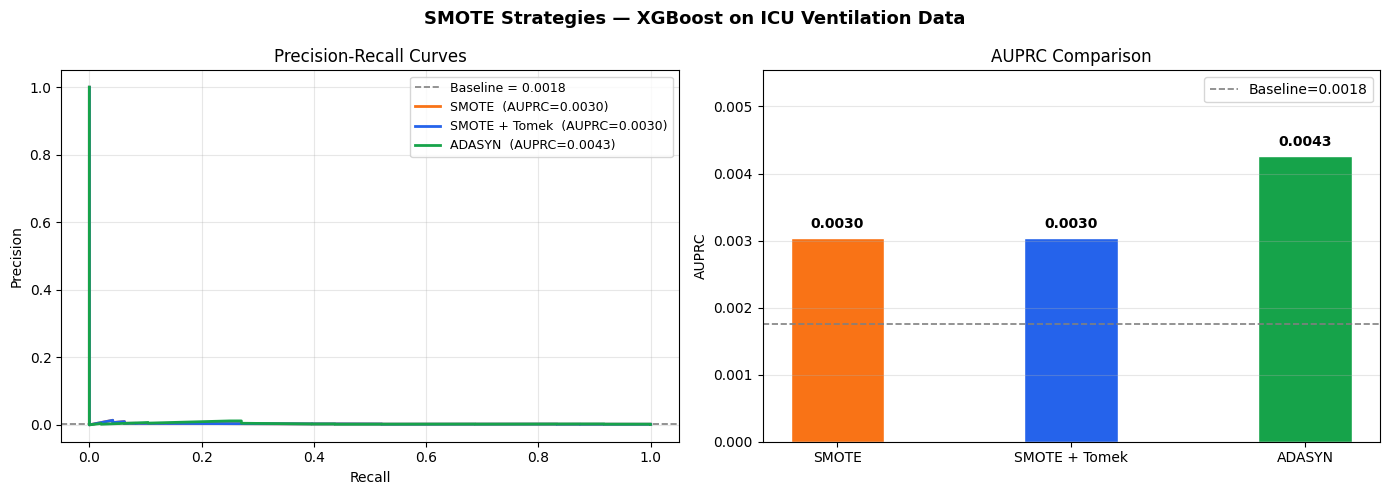


Saved → smote_pr_comparison.png


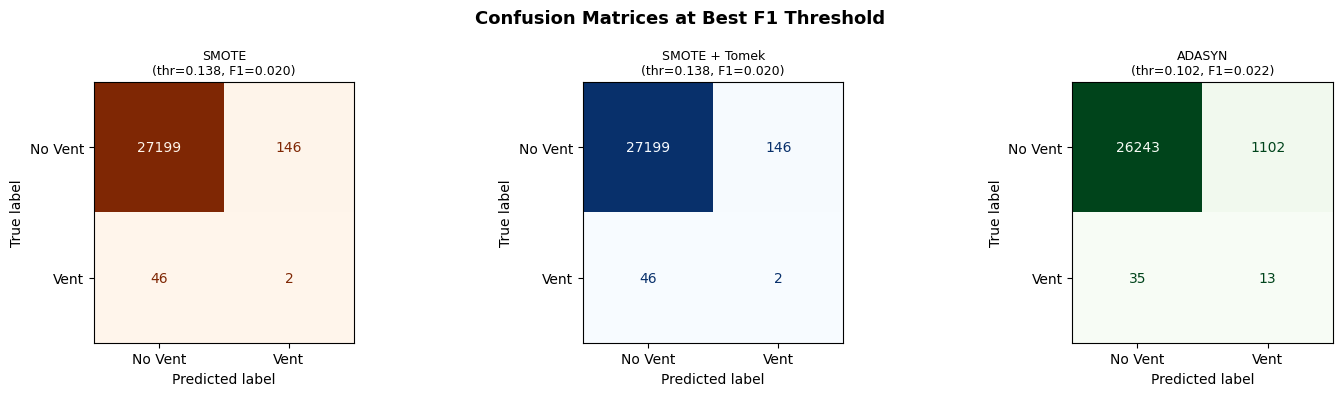

Saved → smote_confusion_matrices.png

--- SMOTE (threshold=0.138) ---
              precision    recall  f1-score   support

     No Vent       1.00      0.99      1.00     27345
        Vent       0.01      0.04      0.02        48

    accuracy                           0.99     27393
   macro avg       0.51      0.52      0.51     27393
weighted avg       1.00      0.99      0.99     27393


--- SMOTE + Tomek (threshold=0.138) ---
              precision    recall  f1-score   support

     No Vent       1.00      0.99      1.00     27345
        Vent       0.01      0.04      0.02        48

    accuracy                           0.99     27393
   macro avg       0.51      0.52      0.51     27393
weighted avg       1.00      0.99      0.99     27393


--- ADASYN (threshold=0.102) ---
              precision    recall  f1-score   support

     No Vent       1.00      0.96      0.98     27345
        Vent       0.01      0.27      0.02        48

    accuracy                         

In [7]:
"""
SMOTE Strategies — ICU Mechanical Ventilation Prediction
=========================================================
Install  : pip install imbalanced-learn xgboost
Strategy : Replace class_weight with SMOTE oversampling variants
Metric   : AUPRC (Area Under Precision-Recall Curve)

3 SMOTE variants tested:
  1. SMOTE          — basic synthetic minority oversampling
  2. SMOTE + Tomek  — SMOTE then remove borderline majority samples
  3. ADASYN         — adaptive oversampling (focuses on hard-to-classify samples)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import xgboost as xgb

# ── 1. Load data ──────────────────────────────────────────────────────────────
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

pos   = int(y_train.sum())
neg   = int((y_train == 0).sum())
ratio = neg / pos

print(f"Train : {X_train.shape}  |  Pos={pos}  Neg={neg}  Ratio={ratio:.1f}:1")
print(f"Test  : {X_test.shape}   |  Pos={y_test.sum()}  Neg={(y_test==0).sum()}")

# ── 2. Define SMOTE strategies ────────────────────────────────────────────────
# sampling_strategy=0.1 means after resampling:
#   minority / majority = 0.1  →  ~10% positive rate
# This avoids over-generating and keeps training realistic

smote_strategies = {
    "SMOTE": SMOTE(
        sampling_strategy=0.1,   # upsample minority to 10% of majority
        k_neighbors=5,
        random_state=42,
    ),
    "SMOTE + Tomek": SMOTETomek(
        smote=SMOTE(sampling_strategy=0.1, k_neighbors=5, random_state=42),
        random_state=42,
    ),
    "ADASYN": ADASYN(
        sampling_strategy=0.1,   # adaptive — focuses on difficult samples
        n_neighbors=5,
        random_state=42,
    ),
}

# ── 3. Classifier (XGBoost — no class_weight since SMOTE handles imbalance) ───
def make_xgb():
    return xgb.XGBClassifier(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=10,
        subsample=0.8,
        colsample_bytree=0.8,
        # NOTE: scale_pos_weight=1 because SMOTE already balanced the data
        scale_pos_weight=1,
        eval_metric="aucpr",
        early_stopping_rounds=30,
        use_label_encoder=False,
        random_state=42,
        n_jobs=-1,
    )

# ── 4. Train & evaluate each strategy ─────────────────────────────────────────
results = {}

for strategy_name, sampler in smote_strategies.items():
    print(f"\n{'─'*55}")
    print(f"Strategy: {strategy_name}")

    # Apply SMOTE only on training data — NEVER on test data
    print("  Resampling training data ...")
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    pos_res = int(y_res.sum())
    neg_res = int((y_res == 0).sum())
    print(f"  After resampling → Pos={pos_res}  Neg={neg_res}  Ratio={neg_res/pos_res:.1f}:1")

    # Train XGBoost
    print("  Training XGBoost ...")
    model = make_xgb()
    model.fit(
        X_res, y_res,
        eval_set=[(X_test, y_test)],
        verbose=False,
    )

    # Evaluate
    y_prob = model.predict_proba(X_test)[:, 1]
    auprc  = average_precision_score(y_test, y_prob)
    auroc  = roc_auc_score(y_test, y_prob)

    # Best threshold by F1
    prec, rec, thr = precision_recall_curve(y_test, y_prob)
    f1  = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    idx = np.argmax(f1)

    results[strategy_name] = {
        "model"    : model,
        "y_prob"   : y_prob,
        "auprc"    : auprc,
        "auroc"    : auroc,
        "prec"     : prec,
        "rec"      : rec,
        "thr"      : thr,
        "best_thr" : thr[idx],
        "best_f1"  : f1[idx],
        "y_pred"   : (y_prob >= thr[idx]).astype(int),
    }

    print(f"  AUPRC : {auprc:.4f}  |  AUROC : {auroc:.4f}  |  Best F1 : {f1[idx]:.3f}  |  Best thr : {thr[idx]:.3f}")

# ── 5. Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Strategy':<20} {'AUPRC':>8}  {'AUROC':>8}  {'Best F1':>8}")
print(f"{'='*60}")
for name, r in results.items():
    print(f"{name:<20} {r['auprc']:>8.4f}  {r['auroc']:>8.4f}  {r['best_f1']:>8.3f}")
print(f"{'='*60}")

# ── 6. PR Curve comparison ────────────────────────────────────────────────────
colors   = ["#f97316", "#2563eb", "#16a34a"]
baseline = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SMOTE Strategies — XGBoost on ICU Ventilation Data",
             fontsize=13, fontweight="bold")

ax = axes[0]
ax.axhline(baseline, color="gray", linestyle="--", lw=1.2,
           label=f"Baseline = {baseline:.4f}")
for (name, r), c in zip(results.items(), colors):
    ax.plot(r["rec"], r["prec"], color=c, lw=2,
            label=f"{name}  (AUPRC={r['auprc']:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# AUPRC bar chart
ax = axes[1]
names  = list(results.keys())
auprcs = [r["auprc"] for r in results.values()]
bars   = ax.bar(names, auprcs, color=colors[:len(names)], width=0.4, edgecolor="white")
ax.axhline(baseline, color="gray", linestyle="--", lw=1.2, label=f"Baseline={baseline:.4f}")
for bar, val in zip(bars, auprcs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("AUPRC")
ax.set_title("AUPRC Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(auprcs) * 1.3)

plt.tight_layout()
plt.savefig("smote_pr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → smote_pr_comparison.png")

# ── 7. Confusion matrices ─────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle("Confusion Matrices at Best F1 Threshold", fontsize=13, fontweight="bold")

for ax, (name, r), c in zip(axes2, results.items(), ["Oranges", "Blues", "Greens"]):
    cm   = confusion_matrix(y_test, r["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Vent", "Vent"])
    disp.plot(ax=ax, colorbar=False, cmap=c)
    ax.set_title(f"{name}\n(thr={r['best_thr']:.3f}, F1={r['best_f1']:.3f})", fontsize=9)

plt.tight_layout()
plt.savefig("smote_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → smote_confusion_matrices.png")

# ── 8. Classification reports ─────────────────────────────────────────────────
for name, r in results.items():
    print(f"\n--- {name} (threshold={r['best_thr']:.3f}) ---")
    print(classification_report(y_test, r["y_pred"], target_names=["No Vent", "Vent"]))

## SMOTE Strategies with Random Forest

Train : (109474, 31)  |  Pos=250  Neg=109224  Ratio=436.9:1
Test  : (27393, 31)   |  Pos=48  Neg=27345

───────────────────────────────────────────────────────
Strategy: SMOTE
  Resampling training data ...
  After resampling → Pos=10922  Neg=109224  Ratio=10.0:1
  Training Random Forest ...
  Done ✓
  AUPRC : 0.0040  |  AUROC : 0.6630  |  Best F1 : 0.014  |  Best thr : 0.103

───────────────────────────────────────────────────────
Strategy: SMOTE + Tomek
  Resampling training data ...
  After resampling → Pos=10922  Neg=109224  Ratio=10.0:1
  Training Random Forest ...
  Done ✓
  AUPRC : 0.0040  |  AUROC : 0.6630  |  Best F1 : 0.014  |  Best thr : 0.103

───────────────────────────────────────────────────────
Strategy: ADASYN
  Resampling training data ...
  After resampling → Pos=10967  Neg=109224  Ratio=10.0:1
  Training Random Forest ...
  Done ✓
  AUPRC : 0.0039  |  AUROC : 0.6881  |  Best F1 : 0.011  |  Best thr : 0.098

Strategy                AUPRC     AUROC   Best F1
SMOTE    

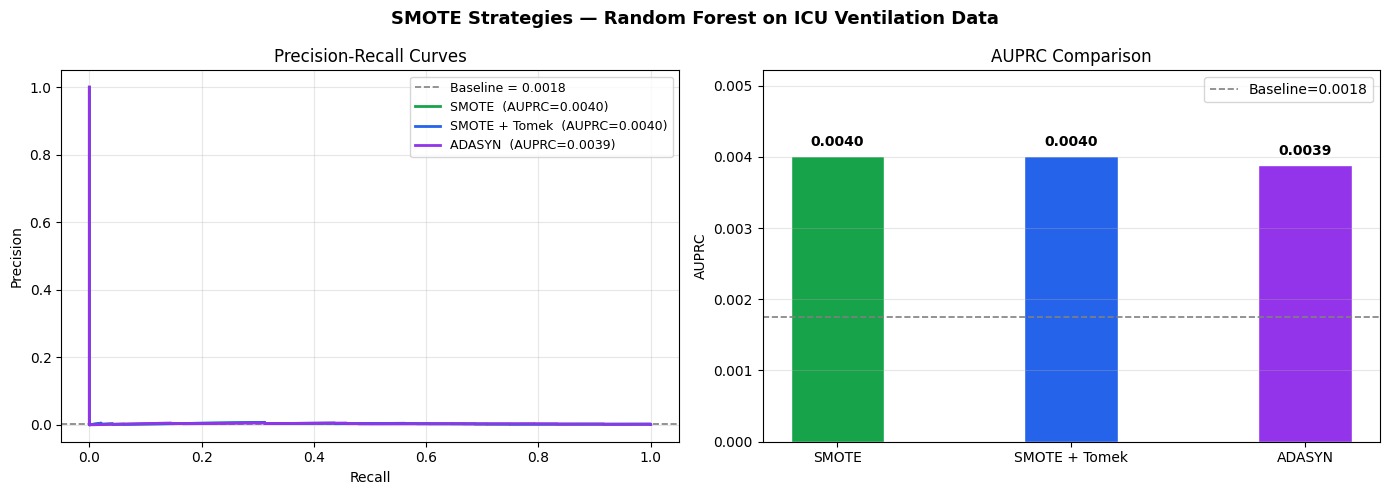


Saved → smote_rf_pr_comparison.png


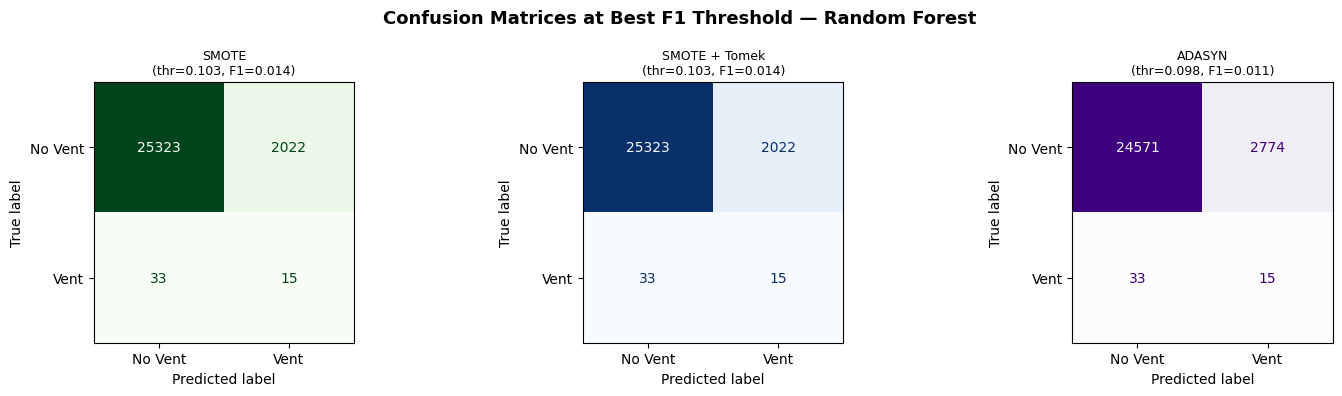

Saved → smote_rf_confusion_matrices.png

Feature importance from best strategy: SMOTE
admissionweight        0.120539
age                    0.109859
fio2_last              0.076562
heartrate_mean_3h      0.058077
gender_Female          0.054518
gender_Male            0.052227
unittype_CSICU         0.046226
respiration_mean_3h    0.042868
heartrate_last         0.042529
on_oxygen_therapy      0.042427
respiration_std_3h     0.034467
respiration_last       0.034318
sao2_std_3h            0.033987
fio2_missing           0.031650
sao2_mean_3h           0.027721


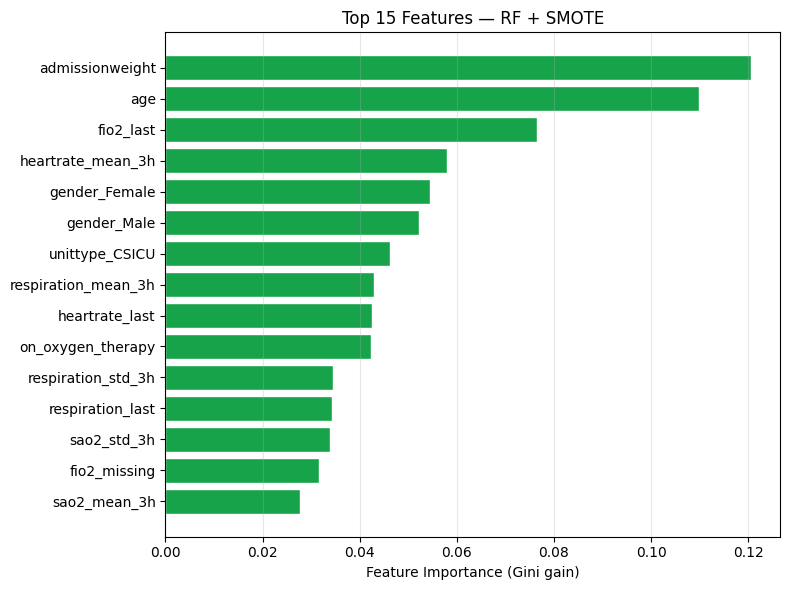

Saved → smote_rf_feature_importance.png

--- SMOTE (threshold=0.103) ---
              precision    recall  f1-score   support

     No Vent       1.00      0.93      0.96     27345
        Vent       0.01      0.31      0.01        48

    accuracy                           0.92     27393
   macro avg       0.50      0.62      0.49     27393
weighted avg       1.00      0.92      0.96     27393


--- SMOTE + Tomek (threshold=0.103) ---
              precision    recall  f1-score   support

     No Vent       1.00      0.93      0.96     27345
        Vent       0.01      0.31      0.01        48

    accuracy                           0.92     27393
   macro avg       0.50      0.62      0.49     27393
weighted avg       1.00      0.92      0.96     27393


--- ADASYN (threshold=0.098) ---
              precision    recall  f1-score   support

     No Vent       1.00      0.90      0.95     27345
        Vent       0.01      0.31      0.01        48

    accuracy                      

In [8]:
"""
SMOTE Strategies + Random Forest — ICU Mechanical Ventilation Prediction
=========================================================================
Install  : pip install imbalanced-learn
Strategy : Replace class_weight with SMOTE oversampling variants
Metric   : AUPRC (Area Under Precision-Recall Curve)

3 SMOTE variants tested:
  1. SMOTE          — basic synthetic minority oversampling
  2. SMOTE + Tomek  — SMOTE then remove borderline majority samples
  3. ADASYN         — adaptive oversampling (focuses on hard-to-classify samples)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.combine import SMOTETomek

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

# ── 1. Load data ──────────────────────────────────────────────────────────────
X_train = pd.read_csv("X_train.csv")
X_test  = pd.read_csv("X_test.csv")
y_train = pd.read_csv("y_train.csv").squeeze()
y_test  = pd.read_csv("y_test.csv").squeeze()

pos   = int(y_train.sum())
neg   = int((y_train == 0).sum())
ratio = neg / pos

print(f"Train : {X_train.shape}  |  Pos={pos}  Neg={neg}  Ratio={ratio:.1f}:1")
print(f"Test  : {X_test.shape}   |  Pos={y_test.sum()}  Neg={(y_test==0).sum()}")

# ── 2. Define SMOTE strategies ────────────────────────────────────────────────
# sampling_strategy=0.1 → upsample minority to 10% of majority
# Avoids over-generating synthetic samples unrealistically

smote_strategies = {
    "SMOTE": SMOTE(
        sampling_strategy=0.1,
        k_neighbors=5,
        random_state=42,
    ),
    "SMOTE + Tomek": SMOTETomek(
        smote=SMOTE(sampling_strategy=0.1, k_neighbors=5, random_state=42),
        random_state=42,
    ),
    "ADASYN": ADASYN(
        sampling_strategy=0.1,
        n_neighbors=5,
        random_state=42,
    ),
}

# ── 3. Classifier (Random Forest — no class_weight since SMOTE handles it) ───
# NOTE: class_weight=None because SMOTE already rebalanced the training data
# Using class_weight='balanced' on top of SMOTE would double-correct the imbalance

def make_rf():
    return RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_leaf=10,
        max_features="sqrt",
        class_weight=None,        # SMOTE handles imbalance — no double correction
        n_jobs=-1,
        random_state=42,
    )

# ── 4. Train & evaluate each strategy ─────────────────────────────────────────
results = {}

for strategy_name, sampler in smote_strategies.items():
    print(f"\n{'─'*55}")
    print(f"Strategy: {strategy_name}")

    # Apply SMOTE only on training data — NEVER on test data
    print("  Resampling training data ...")
    X_res, y_res = sampler.fit_resample(X_train, y_train)
    pos_res = int(y_res.sum())
    neg_res = int((y_res == 0).sum())
    print(f"  After resampling → Pos={pos_res}  Neg={neg_res}  Ratio={neg_res/pos_res:.1f}:1")

    # Train Random Forest
    print("  Training Random Forest ...")
    model = make_rf()
    model.fit(X_res, y_res)
    print("  Done ✓")

    # Evaluate on original (unmodified) test set
    y_prob = model.predict_proba(X_test)[:, 1]
    auprc  = average_precision_score(y_test, y_prob)
    auroc  = roc_auc_score(y_test, y_prob)

    # Best threshold by F1
    prec, rec, thr = precision_recall_curve(y_test, y_prob)
    f1  = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-8)
    idx = np.argmax(f1)

    results[strategy_name] = {
        "model"    : model,
        "y_prob"   : y_prob,
        "auprc"    : auprc,
        "auroc"    : auroc,
        "prec"     : prec,
        "rec"      : rec,
        "thr"      : thr,
        "best_thr" : thr[idx],
        "best_f1"  : f1[idx],
        "y_pred"   : (y_prob >= thr[idx]).astype(int),
    }

    print(f"  AUPRC : {auprc:.4f}  |  AUROC : {auroc:.4f}  |  Best F1 : {f1[idx]:.3f}  |  Best thr : {thr[idx]:.3f}")

# ── 5. Summary table ──────────────────────────────────────────────────────────
print(f"\n{'='*60}")
print(f"{'Strategy':<20} {'AUPRC':>8}  {'AUROC':>8}  {'Best F1':>8}")
print(f"{'='*60}")
for name, r in results.items():
    print(f"{name:<20} {r['auprc']:>8.4f}  {r['auroc']:>8.4f}  {r['best_f1']:>8.3f}")
print(f"{'='*60}")

# ── 6. PR Curve comparison ────────────────────────────────────────────────────
colors   = ["#16a34a", "#2563eb", "#9333ea"]
baseline = y_test.mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("SMOTE Strategies — Random Forest on ICU Ventilation Data",
             fontsize=13, fontweight="bold")

# PR Curves
ax = axes[0]
ax.axhline(baseline, color="gray", linestyle="--", lw=1.2,
           label=f"Baseline = {baseline:.4f}")
for (name, r), c in zip(results.items(), colors):
    ax.plot(r["rec"], r["prec"], color=c, lw=2,
            label=f"{name}  (AUPRC={r['auprc']:.4f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# AUPRC bar chart
ax = axes[1]
names  = list(results.keys())
auprcs = [r["auprc"] for r in results.values()]
bars   = ax.bar(names, auprcs, color=colors[:len(names)], width=0.4, edgecolor="white")
ax.axhline(baseline, color="gray", linestyle="--", lw=1.2,
           label=f"Baseline={baseline:.4f}")
for bar, val in zip(bars, auprcs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.set_ylabel("AUPRC")
ax.set_title("AUPRC Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, max(auprcs) * 1.3)

plt.tight_layout()
plt.savefig("smote_rf_pr_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nSaved → smote_rf_pr_comparison.png")

# ── 7. Confusion matrices ─────────────────────────────────────────────────────
fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle("Confusion Matrices at Best F1 Threshold — Random Forest",
              fontsize=13, fontweight="bold")

for ax, (name, r), cmap in zip(axes2, results.items(), ["Greens", "Blues", "Purples"]):
    cm   = confusion_matrix(y_test, r["y_pred"])
    disp = ConfusionMatrixDisplay(cm, display_labels=["No Vent", "Vent"])
    disp.plot(ax=ax, colorbar=False, cmap=cmap)
    ax.set_title(f"{name}\n(thr={r['best_thr']:.3f}, F1={r['best_f1']:.3f})", fontsize=9)

plt.tight_layout()
plt.savefig("smote_rf_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → smote_rf_confusion_matrices.png")

# ── 8. Feature importance — best SMOTE strategy ───────────────────────────────
best_name  = max(results, key=lambda n: results[n]["auprc"])
best_model = results[best_name]["model"]

imp   = pd.Series(best_model.feature_importances_, index=X_train.columns)
imp   = imp.sort_values(ascending=False)
top15 = imp.head(15)

print(f"\nFeature importance from best strategy: {best_name}")
print(top15.to_string())

fig3, ax3 = plt.subplots(figsize=(8, 6))
ax3.barh(top15.index[::-1], top15.values[::-1], color="#16a34a", edgecolor="white")
ax3.set_xlabel("Feature Importance (Gini gain)")
ax3.set_title(f"Top 15 Features — RF + {best_name}")
ax3.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("smote_rf_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → smote_rf_feature_importance.png")

# ── 9. Classification reports ─────────────────────────────────────────────────
for name, r in results.items():
    print(f"\n--- {name} (threshold={r['best_thr']:.3f}) ---")
    print(classification_report(y_test, r["y_pred"], target_names=["No Vent", "Vent"]))